In [1]:
import pandas as pd
import matplotlib.pyplot as plt
import numpy as np
from statsmodels.tsa.stattools import adfuller
import warnings
warnings.filterwarnings('ignore')

In [2]:
sales_of_company_x = pd.read_csv("Series/monthly-sales-of-company-x-jan-6.csv")
robberies_in_boston = pd.read_csv("Series/monthly-boston-armed-robberies-j.csv")
airlines_passengers = pd.read_csv("Series/international-airline-passengers.csv")
mean_monthly_temp = pd.read_csv("Series/mean-monthly-air-temperature-deg.csv")
dowjones_closing = pd.read_csv("Series/weekly-closings-of-the-dowjones-.csv")
female_births = pd.read_csv("Series/daily-total-female-births-in-cal.csv")

df_list = [sales_of_company_x, robberies_in_boston, airlines_passengers, mean_monthly_temp, dowjones_closing, female_births]

df_name = ('sales_of_company_x', 'robberies_in_boston', 'airlines_passengers', 'mean_monthly_temp', 'dowjones_closing', 'female_births')

for df in df_list:
    print(df.shape, end='     ')

(77, 2)     (118, 2)     (144, 2)     (240, 2)     (162, 2)     (365, 2)     

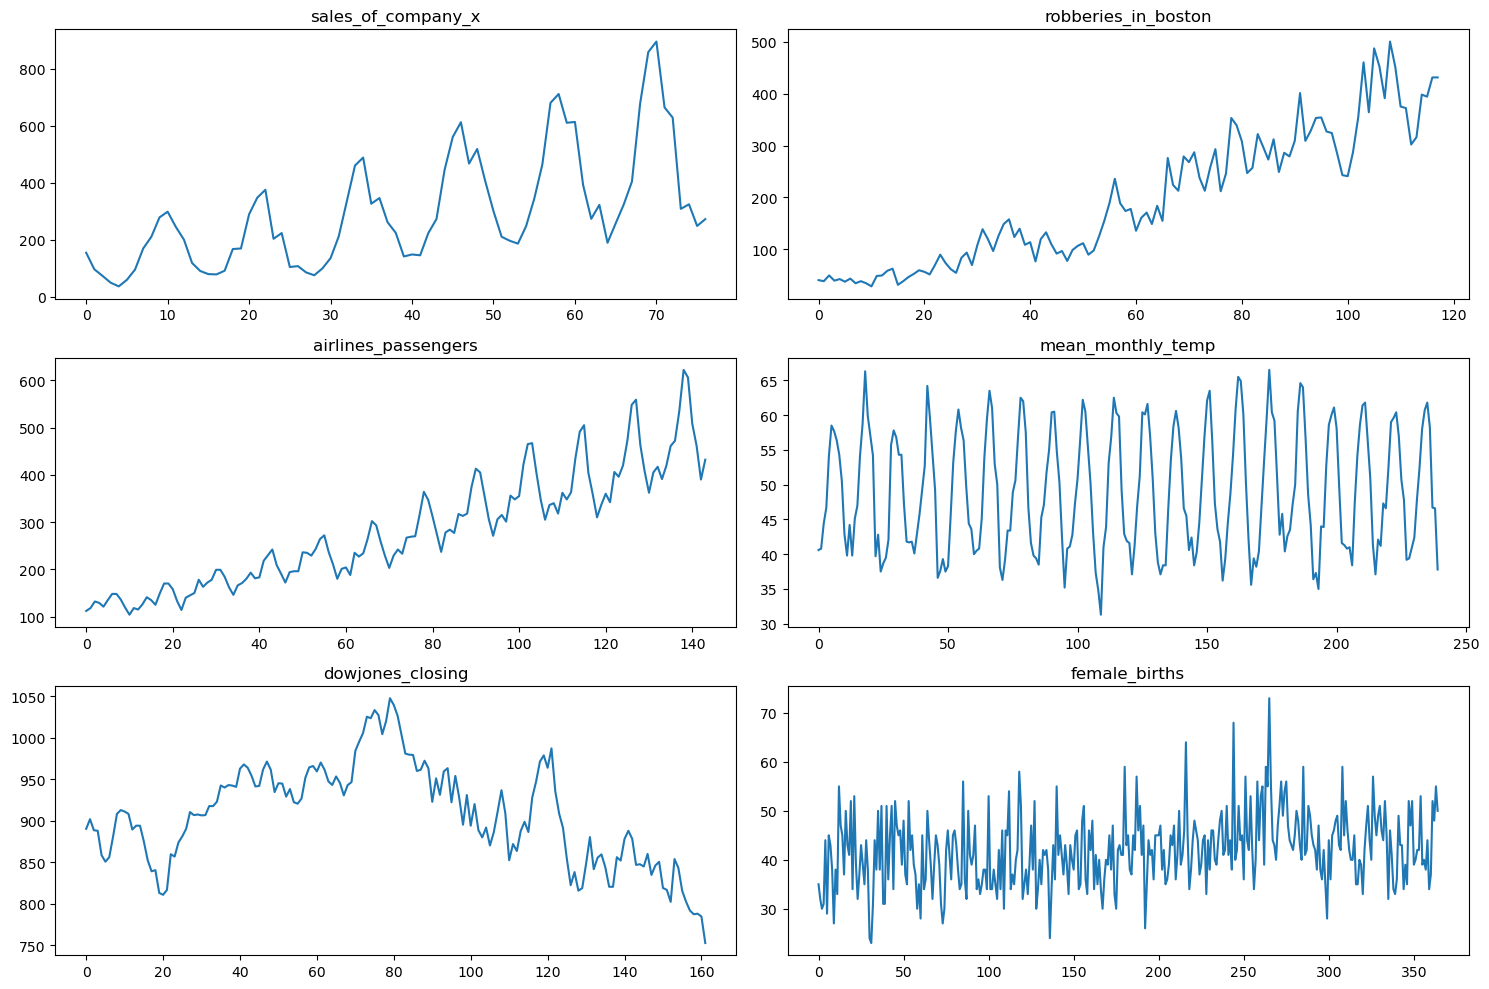

In [3]:
def six_graf(df_list):
    fig, axes = plt.subplots(3, 2, figsize=(15, 10))
    for i, ax in enumerate(axes.flat):
        ax.plot(df_list[i].iloc[:, 1])
        ax.set_title(df_name[i])
    plt.tight_layout()
    plt.show()
    
six_graf(df_list)

In [4]:
def check_stationarity(df_list):
    for i in range(6):
        res = adfuller(df_list[i].iloc[:, 1], autolag='AIC')[1]
        if res <= 0.05:
            print(f'{df_name[i]:<20}-> Отвергаем H0. Ряд СТАЦИОНАРЕН')
        else:
            print(f'{df_name[i]:<20}-> Не можем отвергнуть H0. Ряд НЕСТАЦИОНАРЕН')

check_stationarity(df_list)

sales_of_company_x  -> Не можем отвергнуть H0. Ряд НЕСТАЦИОНАРЕН
robberies_in_boston -> Не можем отвергнуть H0. Ряд НЕСТАЦИОНАРЕН
airlines_passengers -> Не можем отвергнуть H0. Ряд НЕСТАЦИОНАРЕН
mean_monthly_temp   -> Отвергаем H0. Ряд СТАЦИОНАРЕН
dowjones_closing    -> Не можем отвергнуть H0. Ряд НЕСТАЦИОНАРЕН
female_births       -> Отвергаем H0. Ряд СТАЦИОНАРЕН


sales_of_company_x  -> Отвергаем H0. Ряд СТАЦИОНАРЕН
robberies_in_boston -> Отвергаем H0. Ряд СТАЦИОНАРЕН
airlines_passengers -> Отвергаем H0. Ряд СТАЦИОНАРЕН
mean_monthly_temp   -> Отвергаем H0. Ряд СТАЦИОНАРЕН
dowjones_closing    -> Отвергаем H0. Ряд СТАЦИОНАРЕН
female_births       -> Отвергаем H0. Ряд СТАЦИОНАРЕН


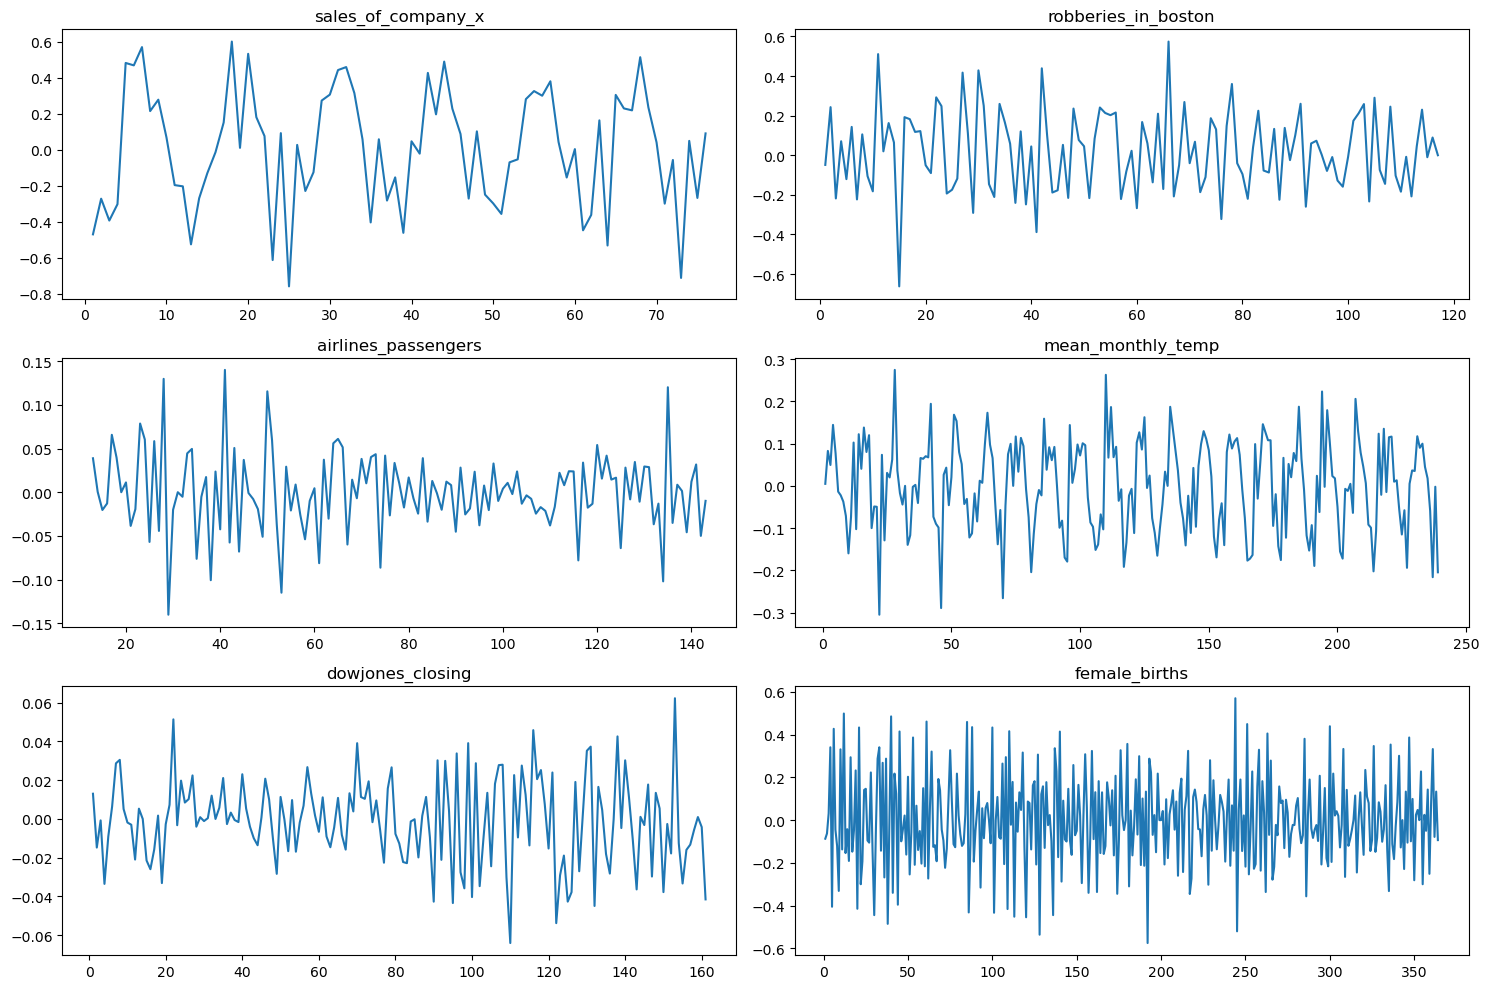

In [5]:
df_list_stationary = []

for df in df_list:
    df_copy = df.copy()
    df.iloc[:, 1] = df.iloc[:, 1].astype(float)
    df.iloc[:, 1] = np.log1p(df.iloc[:, 1])
    df.iloc[:, 1] =  df.iloc[:, 1].diff()
    df = df.dropna()
    if len(df_list_stationary) == 2:   # чисто для третьего графика, там по тесту Дики-Фуллера ряд не стационарный получался
        df.iloc[:, 1] =  df.iloc[:, 1].diff(12)
    df = df.dropna()
    df_list_stationary.append(df)

check_stationarity(df_list_stationary)
six_graf(df_list_stationary)